# Florida school spine — investigating `schools preprocess` / `schools assemble`

This notebook no longer re-implements the pipeline: it **imports**
`src/regions/florida/sources/schools/{preprocess,assemble}.py` — the way
`assessments.ipynb` imports `assessments/preprocess.py` — runs each stage, and
adds reasonability descriptives the module itself doesn't print. Design &
column dictionary: [`docs/data/florida/schools/README.md`](../../../docs/data/florida/schools/README.md).

| file | grain | written by |
|---|---|---|
| `processed/school_cross_section.parquet` | one row per `msid` | `preprocess` stage 1a |
| `processed/school_year_panel.parquet` | one row per `msid × year` (spring year, 1990–2026) | `preprocess` stages 1a+1b |
| `assembled/schools_treatment.parquet` | one row per `(msid, gcid)` pair | `assemble` stage 2 |
| `assembled/schools_treatment_rollup.parquet` | one row per `msid` | `assemble` stage 2 |

Run with the `311` conda env (geopandas, pandas 3).

Final-panel-level descriptives (covariate coverage, treatment-timing structure, geography of treated schools) now live in [`output/notebooks/descriptive_statistics.ipynb`](../../../output/notebooks/florida/descriptive_statistics.ipynb) instead of here — this notebook stays focused on *why* the spine and match are built the way they are.


In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.simplefilter("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)
plt.rcParams["figure.dpi"] = 110
BLUE, RED, GREEN, GREY = "#4C78A8", "#E45756", "#1f6f3f", "#B0B0B0"


def repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.regions.florida.sources.schools import msid_codes as MC              # noqa: E402
from src.regions.florida.sources.schools import preprocess as PRE             # noqa: E402
from src.regions.florida.sources.schools import assemble as ASM               # noqa: E402
from src.regions.florida.sources.schools.shared import schools_paths          # noqa: E402

P = schools_paths(ROOT)
FIGDIR = ROOT / "output/figures/florida"
FIGDIR.mkdir(parents=True, exist_ok=True)


def savefig(fig, name):
    path = FIGDIR / name
    fig.savefig(path, bbox_inches="tight", dpi=130)
    print("  saved", path.relative_to(ROOT))


def describe_num(s, name=""):
    s = pd.to_numeric(s, errors="coerce")
    q = s.quantile([0, .05, .5, .95, 1]).round(2)
    print(f"{name:24s} n={s.notna().sum():>7,}  nan={s.isna().sum():>6,}  "
          f"min={q[0]!s:>8}  p5={q[.05]!s:>8}  med={q[.5]!s:>8}  p95={q[.95]!s:>9}  max={q[1]!s:>10}")


## 1. Stage 1a — spine, crosswalk, classification, coordinates

`build_cross_section` needs the classified, geocoded MSID spine; walking
through the pieces here (rather than only calling the top-level
`run_schools_preprocess`) so each stage's output can be inspected.


In [2]:
msid_raw = PRE.load_msid(ROOT)
msid_id = PRE.compose_ncessch(msid_raw)
print(f"MSID {msid_id.shape[0]:,} rows | ncessch sentinel "
      f"{msid_id['ncessch'].isna().mean():.1%} | ncessch_shared rows {int(msid_id['ncessch_shared'].sum())}")

ccd_directory = PRE.tidy_ccd_directory(ROOT)
msid_classified = PRE.decode_classification(msid_id, ccd_directory)
print("\ngrade_low_source:", msid_classified["grade_low_source"].value_counts().to_dict())
print("serves_tested_grades:", msid_classified["serves_tested_grades"].value_counts(dropna=False).to_dict())
print("flags (n True):", {c: int(msid_classified[c].sum()) for c in
      ["is_regular", "is_alternative", "is_charter", "is_magnet", "is_virtual"]})


MSID 7,204 rows | ncessch sentinel 9.4% | ncessch_shared rows 72

grade_low_source: {'msid_grade_code': 6135, 'none': 902, 'ccd_directory': 167}
serves_tested_grades: {np.True_: 5720, <NA>: 902, np.False_: 582}
flags (n True): {'is_regular': 4997, 'is_alternative': 957, 'is_charter': 1292, 'is_magnet': 669, 'is_virtual': 324}


In [3]:
edge = PRE.load_edge(root=ROOT)
msid_geo = PRE.resolve_coordinates(msid_classified, edge)
print("geom_source:", msid_geo["geom_source"].value_counts().to_dict())
print("geocode_pending (active, no coordinate):", int(msid_geo["geocode_pending"].sum()))
describe_num(msid_geo["geom_disagree_m"], "EDGE<->MSID gap (m)")
print(f"  > 250 m apart: {(msid_geo['geom_disagree_m'] > 250).mean():.1%}")


geom_source: {'edge': 4325, 'msid': 1659, 'none': 1220}
geocode_pending (active, no coordinate): 239
EDGE<->MSID gap (m)      n=  4,274  nan= 2,930  min=     0.1  p5=     3.8  med=    48.6  p95=   633.52  max=  355394.8
  > 250 m apart: 4.8%


### 1.1 Crosswalk reasonability against independent sources

`school_barrier_features.parquet` (from `barriers.ipynb`) carries EDGE's own
`NCESSCH` for 2024–25 — how many composed ids match one of those? And is every
tested `msid` in the spine (bar the known district-78/80 state colleges)?


In [4]:
assess_school = PRE.load_assessment_schools(ROOT)
edge_nc = set(pd.read_parquet(
    ROOT / "data/florida/schools/processed/school_barrier_features.parquet",
    columns=["NCESSCH"])["NCESSCH"].astype(str))
comp = msid_id.loc[msid_id["ncessch"].notna(), ["ncessch", "ACTIVITY_CODE"]]
print(f"composed ncessch matches an EDGE id: all {comp['ncessch'].isin(edge_nc).mean():.1%}   "
      f"active-only {comp.loc[comp.ACTIVITY_CODE=='A', 'ncessch'].isin(edge_nc).mean():.1%}")

tested = set(assess_school["msid"])
missing = sorted(tested - set(msid_id["msid"]))
print(f"tested msid absent from spine: {len(missing)} / {len(tested)}  "
      f"districts {sorted({m[:2] for m in missing})}  (78/80 = state colleges, expected)")


composed ncessch matches an EDGE id: all 66.3%   active-only 86.0%
tested msid absent from spine: 22 / 4419  districts ['78', '80']  (78/80 = state colleges, expected)


## 2. Cross-section & operation panel


In [5]:
cross_section = PRE.build_cross_section(msid_geo, assess_school)
panel_skeleton = PRE.build_operation_panel(msid_geo, assess_school)
print("cross_section:", cross_section.shape, "| unique msid:", cross_section["msid"].is_unique)
print("panel skeleton:", panel_skeleton.shape,
      "| operating rows:", int(panel_skeleton["in_operation"].sum()),
      "| conflict->True:", int((panel_skeleton["in_operation_src"] == "conflict").sum()))

print("\nby activity x school_type:")
print(pd.crosstab(cross_section["activity"], cross_section["school_type"]).to_string())

# "operating schools per spring year" now lives in descriptive_statistics.ipynb
# (panel-balance section) rather than here.


cross_section: (7204, 30) | unique msid: True
panel skeleton: (266548, 5) | operating rows: 176800 | conflict->True: 64

by activity x school_type:
school_type  adult  combination  elementary  middle_jr_high  not_yet_assigned  other  senior_high
activity                                                                                         
active         122          909        1863             548                 0    424          917
closed         190          269         479             206                 0    530          596
future           0           12          11               4               103     12            9


## 3. Stage 1b — Cluster-A covariates


In [6]:
race_shares = PRE.tidy_ccd_enrollment_race(ROOT)
crdc_swd = PRE.tidy_crdc_swd(ROOT)
crdc_lep = PRE.tidy_crdc_lep(ROOT)
edfacts = PRE.tidy_edfacts(ROOT)
panel = PRE.join_covariates(panel_skeleton, cross_section, ccd_directory, race_shares, crdc_swd, crdc_lep, edfacts)

for name, tbl in [("ccd_directory", ccd_directory), ("race_shares", race_shares),
                  ("crdc_swd", crdc_swd), ("crdc_lep", crdc_lep), ("edfacts", edfacts)]:
    print(f"{name:14s}", "present" if tbl is not None else "MISSING — run `schools fetch --subsource ...`")

describe_num(ccd_directory["enrollment"], "enrollment")
describe_num(ccd_directory["pupil_teacher_ratio"].clip(upper=60), "pupil_teacher_ratio")
describe_num((ccd_directory["frpl_n"] / ccd_directory["enrollment"]).clip(0, 1.5), "frpl_n / enrollment")
describe_num(race_shares["pct_black"], "pct_black")
describe_num(crdc_swd["pct_swd"], "pct_swd")
describe_num(crdc_lep["pct_ell"], "pct_ell")
describe_num(edfacts["read_prof_midpt"], "read_prof_midpt")


ccd_directory  present
race_shares    present
crdc_swd       present
crdc_lep       present
edfacts        present
enrollment               n=126,342  nan= 5,529  min=     0.0  p5=    11.0  med=   633.0  p95=   1870.0  max=   12730.0
pupil_teacher_ratio      n=114,358  nan=17,513  min=     0.0  p5=    6.28  med=    16.3  p95=     23.5  max=      60.0
frpl_n / enrollment      n=100,133  nan=31,738  min=     0.0  p5=    0.08  med=    0.56  p95=     0.93  max=       1.5
pct_black                n=122,241  nan= 1,836  min=     0.0  p5=    0.01  med=    0.19  p95=     0.85  max=      1.75
pct_swd                  n= 23,665  nan=    71  min=     0.0  p5=    0.02  med=    0.13  p95=     0.39  max=      1.22
pct_ell                  n= 23,665  nan=    71  min=     0.0  p5=     0.0  med=    0.05  p95=     0.37  max=       1.0
read_prof_midpt          n= 41,275  nan=   105  min=    -3.0  p5=    10.0  med=    52.0  p95=     84.0  max=      99.5


### 3.1 Reasonability: CCD enrollment vs. assessment test-takers

Each tested grade feeds both ELA and Math, so the sum ≈ 2×(tested-grade
population) ≈ enrollment for a 3-grade elementary school → a ratio near 1 is
expected; a wide tested span pushes it above 1.


In [7]:
ntest = (assess_school[assess_school.subject.isin(["ELA", "MATH"])]
         .groupby(["msid", "year"])["n_students"].sum().rename("n_tested_elamath"))
cmp = (panel.merge(ntest, on=["msid", "year"], how="inner")
       .loc[lambda x: x["enrollment"].gt(0) & x["n_tested_elamath"].gt(0)])
ratio = cmp["n_tested_elamath"] / cmp["enrollment"]
print(f"ELA+Math test-takers / CCD enrollment (n={len(cmp):,}): "
      f"median {ratio.median():.2f}  p10 {ratio.quantile(.1):.2f}  p90 {ratio.quantile(.9):.2f}")
print("extreme ratios (>3 or <0.1):", int(((ratio > 3) | (ratio < 0.1)).sum()), "rows")


ELA+Math test-takers / CCD enrollment (n=37,066): median 0.99  p10 0.48  p90 1.75
extreme ratios (>3 or <0.1): 411 rows


## 4. Run the full `preprocess` (validates + persists)

Re-derives everything above through the single entry point and writes
`school_cross_section.parquet` / `school_year_panel.parquet` + `schools.json`.


In [8]:
report = PRE.run_schools_preprocess(root=ROOT)
print(json.dumps({k: v for k, v in report.items() if k not in ("panel_columns", "saved")}, indent=1, default=str))
for k, v in report["saved"].items():
    print("wrote", Path(v).relative_to(ROOT))


{
 "generated_at_utc": "2026-09-12T08:41:36+00:00",
 "generated_by": "src/regions/florida/sources/schools/preprocess.py",
 "panel_years": [
  1990,
  2026
 ],
 "crs": "EPSG:3087",
 "rows": {
  "cross_section": 7204,
  "panel": 266548
 },
 "crosswalk": {
  "ncessch_sentinel_share": 0.09383675735702388,
  "ncessch_shared_rows": 72,
  "assessment_msid_missing_state_colleges": [
   "780002",
   "780004",
   "780005",
   "780006",
   "780007",
   "780008",
   "780009",
   "780011",
   "780012",
   "780014",
   "780016",
   "780017",
   "780020",
   "780027",
   "780028",
   "780029",
   "780032",
   "800005",
   "800007",
   "800011",
   "800020",
   "800025"
  ]
 },
 "coordinates": {
  "geom_source": {
   "edge": 4325,
   "msid": 1659,
   "none": 1220
  },
  "geocode_pending": 239
 },
 "grade_span": {
  "source": {
   "msid_grade_code": 6135,
   "none": 902,
   "ccd_directory": 167
  },
  "unresolved": 902
 },
 "panel": {
  "operating_rows": 176800,
  "conflict_to_true": 64
 },
 "stage1b_s

## 5. Stage 2 — `schools assemble` (school ↔ barrier point-only match)

Algorithms 1–2 (`euclid_nearest`, `buffer_dose`). `road_id` / `same_side` /
`shielded_frac` (algorithms 3–6) are `NA` placeholders in the persisted output —
`road_network` now exists (fetch only) and algorithms 3-5 are prototyped
against it in §7 below, but that prototype is not wired into `assemble.py` yet.


In [9]:
placed = ASM.load_placed_cross_section(ROOT)
barriers = ASM.load_barriers(ROOT)
pair, rollup = ASM.match_barriers_point(placed, barriers)
print(f"{len(pair):,} pairs | {rollup['msid'].nunique():,} placed schools | "
      f"{pair.loc[pair.category.eq('fdot_barrier'), 'timing_unknown'].mean():.1%} undated fdot pairs")

rows = [(r, int((rollup["nearest_fdot_dist_m"] <= r).sum()),
         f"{(rollup['nearest_fdot_dist_m'] <= r).mean():.1%}")
        for r in (100, 200, 300, 500, 1000, 2000, 5000)]
print(pd.DataFrame(rows, columns=["buffer_m", "n_schools", "share_placed"]).to_string(index=False))
describe_num(rollup["nearest_fdot_dist_m"], "nearest FDOT wall (m)")


2,173 pairs | 5,984 placed schools | 2.5% undated fdot pairs
 buffer_m  n_schools share_placed
      100         18         0.3%
      200         72         1.2%
      300        116         1.9%
      500        220         3.7%
     1000        578         9.7%
     2000       1317        22.0%
     5000       3017        50.4%
nearest FDOT wall (m)    n=  5,984  nan=     0  min=    35.0  p5=  607.87  med= 4902.85  p95= 82715.25  max=  164989.6


schools within 1 km of a wall, by district (top 8):
{'MIAMI-DADE': 124, 'BROWARD': 97, 'ORANGE': 79, 'PALM BEACH': 73, 'HILLSBOROUGH': 69, 'DUVAL': 33, 'PINELLAS': 25, 'BREVARD': 12}
  saved output/figures/florida/schools_barrier_match.png


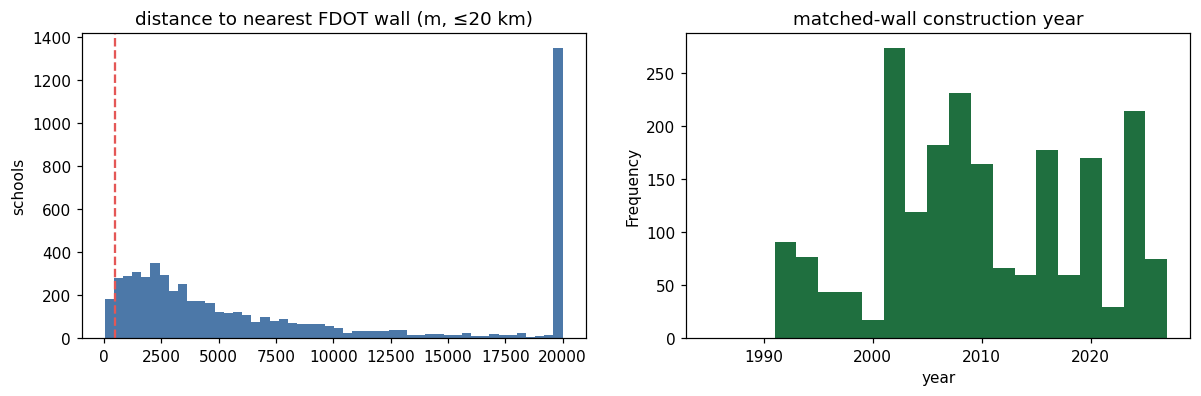

In [10]:
near = rollup[rollup.ever_near_wall_1000m].merge(cross_section[["msid", "district_name"]], on="msid", how="left")
print("schools within 1 km of a wall, by district (top 8):")
print(near["district_name"].value_counts().head(8).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
rollup["nearest_fdot_dist_m"].clip(upper=20000).plot.hist(bins=50, ax=ax[0], color=BLUE)
ax[0].axvline(500, color=RED, ls="--")
ax[0].set(title="distance to nearest FDOT wall (m, ≤20 km)", ylabel="schools")
pair.loc[pair.category.eq("fdot_barrier"), "treat_year"].dropna().plot.hist(
    bins=range(1985, 2028, 2), ax=ax[1], color=GREEN)
ax[1].set(title="matched-wall construction year", xlabel="year")
savefig(fig, "schools_barrier_match.png")


  saved output/figures/florida/schools_algo1_algo2.png


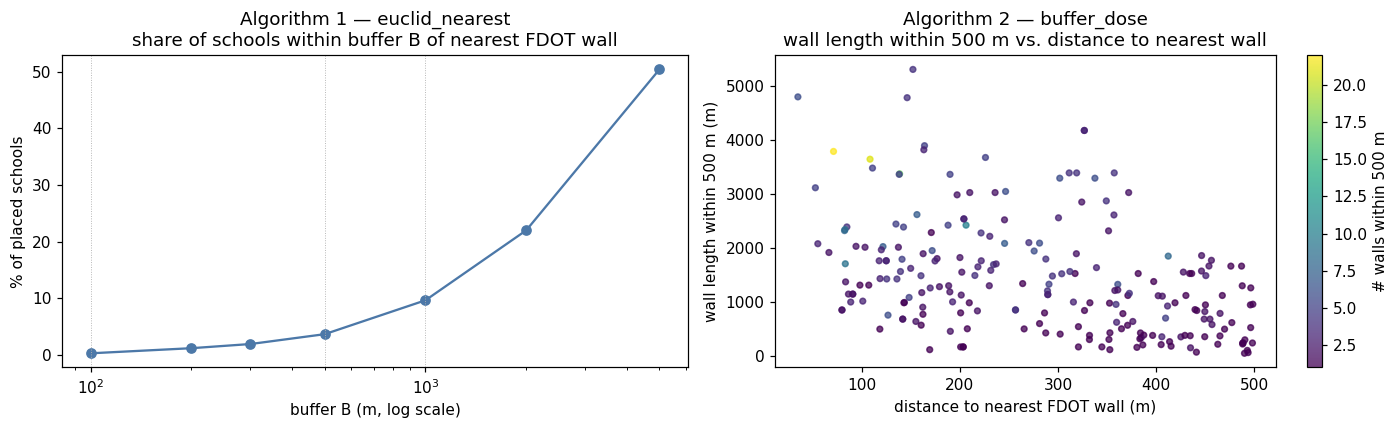

In [11]:
# Algorithm 1 (euclid_nearest) + Algorithm 2 (buffer_dose): visualize both point-only algorithms.
BUFFERS_PLOT = (100, 200, 300, 500, 1000, 2000, 5000)
share_pct = [(rollup["nearest_fdot_dist_m"] <= r).mean() * 100 for r in BUFFERS_PLOT]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(BUFFERS_PLOT, share_pct, marker="o", color=BLUE)
for r in (100, 500, 1000):
    ax[0].axvline(r, color=GREY, lw=0.6, ls=":")
ax[0].set_xscale("log")
ax[0].set(title="Algorithm 1 — euclid_nearest\nshare of schools within buffer B of nearest FDOT wall",
          xlabel="buffer B (m, log scale)", ylabel="% of placed schools")

exposed = rollup[rollup["n_walls_500m"] > 0]
sc = ax[1].scatter(exposed["nearest_fdot_dist_m"], exposed["wall_len_500m"],
                    c=exposed["n_walls_500m"], cmap="viridis", s=14, alpha=0.75)
ax[1].set(title="Algorithm 2 — buffer_dose\nwall length within 500 m vs. distance to nearest wall",
          xlabel="distance to nearest FDOT wall (m)", ylabel="wall length within 500 m (m)")
fig.colorbar(sc, ax=ax[1], label="# walls within 500 m")
fig.tight_layout()
savefig(fig, "schools_algo1_algo2.png")

## 6. Run the full `assemble` (validates + persists)


In [12]:
asm_report = ASM.run_schools_assemble(root=ROOT)
print(json.dumps(asm_report, indent=1, default=str))


{
 "generated_at_utc": "2026-09-12T08:41:59+00:00",
 "generated_by": "src/regions/florida/sources/schools/assemble.py",
 "algorithms": {
  "implemented": [
   "euclid_nearest",
   "buffer_dose",
   "road_gated",
   "same_segment",
   "same_side"
  ],
  "pending": [
   "shielded_arc"
  ]
 },
 "max_dist_m": 1000,
 "buffers_m": [
  100,
  200,
  300,
  500,
  1000
 ],
 "corridor_budget_m": 800.0,
 "corridor_buffer_m": 600.0,
 "schools_placed": 5984,
 "pairs": 2173,
 "schools_matched": 5984,
 "schools_within_500m": 220,
 "schools_within_1000m": 578,
 "undated_fdot_pair_share": 0.025127966496044672,
 "ever_treated_by_definition": {
  "point": 578,
  "same_route": 334,
  "same_side": 250
 },
 "saved": {
  "treatment": "/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution/data/florida/schools/assembled/schools_treatment.parquet",
  "rollup": "/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-p

## 7. Road-network matching algorithms 3–5 (prototype)

`road_network` (FDOT `rciroads`, fetched — see
[`road_network.ipynb`](road_network.ipynb) for its own descriptives) has no
`preprocess.py` yet, so this section prototypes the logic that would extend
`match_barriers_point` into a `match_barriers_road`, filling
`PENDING_ROAD_COLUMNS` (`road_id`, `same_route`, `school_side`, `wall_side`)
per the matching-algorithm ladder in
[`docs/data/florida/schools/README.md`](../../../docs/data/florida/schools/README.md)
and [`docs/data/florida/road_network/README.md`](../../../docs/data/florida/road_network/README.md).
It reuses `placed` / `barriers` / `pair` / `rollup` from §5-6 above — the
point-only match is the baseline this section validates against.

In [13]:
import contextily as cx
from shapely.geometry import MultiLineString
from shapely.ops import linemerge

from src.regions.florida.sources.road_network.shared import (
    DEFAULT_VERSION as RN_VERSION, raw_shapefile_path,
)
from src.regions.florida.sources.noise_barriers.shared import (
    DEFAULT_VERSION as NB_VERSION, raw_gdb_path as nb_raw_gdb_path, raw_metadata_path as nb_raw_metadata_path,
)

RN_SHP = raw_shapefile_path(RN_VERSION, ROOT)
assert RN_SHP.exists(), f"{RN_SHP} missing — run `python -m src.cli florida data road-network fetch` first"

BASEMAP_LIGHT = cx.providers.Esri.WorldGrayCanvas
BASEMAP_STREET = cx.providers.Esri.WorldStreetMap


def add_basemap(ax, crs=3087, source=BASEMAP_LIGHT, **kw):
    cx.add_basemap(ax, crs=crs, source=source, attribution_size=6, **kw)


with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Measured .* geometry types are not supported")
    rn = gpd.read_file(RN_SHP)
print(f"road_network: {len(rn):,} segments, {rn['ROADWAY'].nunique():,} distinct ROADWAY ids, CRS {rn.crs.to_epsg()}")

road_network: 40,357 segments, 18,373 distinct ROADWAY ids, CRS 3087


### 7.1 Algorithm 3 prototype — `road_gated` (nearest-road spatial join)

For each wall and each placed school, find the nearest `road_network`
segment. **Caveat:** `gpd.sjoin_nearest` keeps only the *left* geometry
column — the matched road's own geometry has to be pulled back via
`index_right`, easy to get silently wrong.

In [14]:
def nearest_road(points: gpd.GeoDataFrame, roads: gpd.GeoDataFrame = rn) -> gpd.GeoDataFrame:
    # One row per input point: its nearest road_network segment + distance.
    # Ties (equal-distance matches) are broken by keeping the first.
    joined = gpd.sjoin_nearest(points[["geometry"]], roads, distance_col="dist_m", how="left")
    joined = joined[~joined.index.duplicated(keep="first")]
    joined = joined.rename(columns={"geometry": "point_geometry"})
    # .loc, not positional -- index_right is a label into `roads`'s own index,
    # which is NOT 0..n-1 once `roads` is a filtered subset (e.g. major, below).
    joined["road_geometry"] = roads.geometry.loc[joined["index_right"]].to_numpy()
    return joined


fdot = barriers[barriers["category"] == "fdot_barrier"].reset_index(drop=True)
fdot["rep_point"] = fdot.geometry.interpolate(0.5, normalized=True)

wall_pts = gpd.GeoDataFrame({"gcid": fdot["gcid"].to_numpy()}, geometry=fdot["rep_point"].to_numpy(), crs=fdot.crs)
wj = nearest_road(wall_pts)
wj["gcid"] = fdot["gcid"].to_numpy()
wj["wall_pt"] = fdot["rep_point"].to_numpy()

describe_num(wj["dist_m"], "wall -> nearest road (m)")
acceptance = (wj["dist_m"] <= 50).mean()
print(f"Acceptance check (road_network README Open Q6): {'PASS' if acceptance >= 0.95 else 'FAIL'} — "
      f"{acceptance:.1%} of {len(fdot)} fdot_barrier walls matched within 50 m (target >= 95%).")

wall -> nearest road (m) n=  1,245  nan=     0  min=    0.11  p5=    5.38  med=   19.98  p95=    48.83  max=   1338.07
Acceptance check (road_network README Open Q6): PASS — 95.6% of 1245 fdot_barrier walls matched within 50 m (target >= 95%).


In [15]:
sj = nearest_road(placed[["geometry"]])
sj["msid"] = placed["msid"].to_numpy()
sj["school_pt"] = placed["geometry"].to_numpy()
describe_num(sj["dist_m"], "school -> nearest road (m)")

school -> nearest road (m) n=  5,984  nan=     0  min=    0.05  p5=   30.06  med=  130.62  p95=   591.21  max=  63444.15


  saved output/figures/florida/schools_algo3_road_gated.png


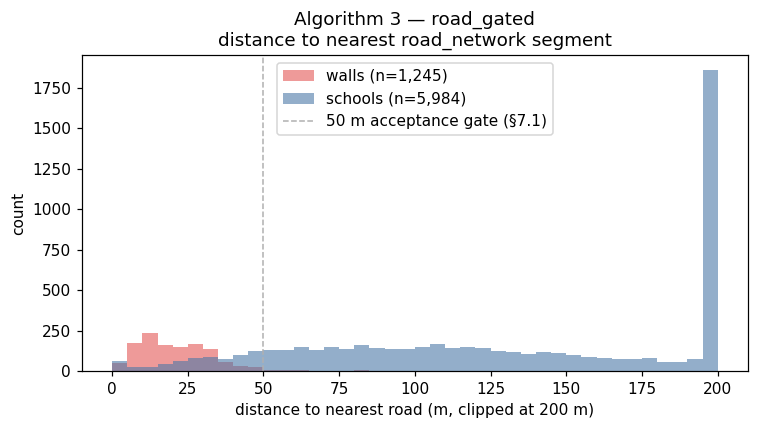

In [16]:
# Algorithm 3 (road_gated): distance from wall / school to the nearest road_network segment.
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 200, 41)
ax.hist(wj["dist_m"].clip(upper=200), bins=bins, alpha=0.6, color=RED, label=f"walls (n={len(wj):,})")
ax.hist(sj["dist_m"].clip(upper=200), bins=bins, alpha=0.6, color=BLUE, label=f"schools (n={len(sj):,})")
ax.axvline(50, color=GREY, ls="--", lw=1, label="50 m acceptance gate (§7.1)")
ax.set(title="Algorithm 3 — road_gated\ndistance to nearest road_network segment",
       xlabel="distance to nearest road (m, clipped at 200 m)", ylabel="count")
ax.legend()
fig.tight_layout()
savefig(fig, "schools_algo3_road_gated.png")

### 7.2 Algorithms 4–5 prototype — linear referencing & side-of-centerline

- **milepost** — project the point onto the matched segment's centerline
  (`line.project(point, normalized=True)`), interpolate between `BEGIN_POST`
  and `END_POST`.
- **side** — sign of the cross product between the centerline's local
  tangent and the vector from the projected point to the original point.
  Only meaningful *pairwise*, comparing a wall's side to a school's side on
  the same matched segment (see the ⚠️ warning in `road_network/README.md`).

37 of 40,357 segments are `MultiLineString` (non-contiguous parts) —
`shapely`'s `.project()` refuses to run on those directly; fall back to the
longest component.

In [17]:
def milepost_and_side(point, line, begin_post: float, end_post: float) -> tuple[float, float, float]:
    if isinstance(line, MultiLineString):
        merged = linemerge(line)
        line = merged if merged.geom_type == "LineString" else max(line.geoms, key=lambda part: part.length)
    frac = line.project(point, normalized=True)
    milepost = begin_post + frac * (end_post - begin_post)
    eps = 1e-4
    f0, f1 = max(0.0, frac - eps), min(1.0, frac + eps)
    tangent = np.array(line.interpolate(f1, normalized=True).coords[0]) - np.array(
        line.interpolate(f0, normalized=True).coords[0])
    proj_pt = line.interpolate(frac, normalized=True)
    offset_vec = np.array([point.x - proj_pt.x, point.y - proj_pt.y])
    offset_m = point.distance(proj_pt)
    cross = tangent[0] * offset_vec[1] - tangent[1] * offset_vec[0]
    side = float(np.sign(cross)) if offset_m > 1e-6 else 0.0
    return milepost, side, offset_m


wall_res = [milepost_and_side(r.wall_pt, r.road_geometry, r.BEGIN_POST, r.END_POST) for r in wj.itertuples()]
wj[["milepost", "side", "offset_m"]] = pd.DataFrame(wall_res, index=wj.index)
school_res = [milepost_and_side(r.school_pt, r.road_geometry, r.BEGIN_POST, r.END_POST) for r in sj.itertuples()]
sj[["milepost", "side", "offset_m"]] = pd.DataFrame(school_res, index=sj.index)

print(f"walls: {len(wj)} rows | schools: {len(sj)} rows | no crashes")
print("\nwall side value counts:\n", wj["side"].value_counts())
print("-> skewed (~87/13, not ~50/50): RCI's digitizing direction is arbitrary per ROADWAY, not a compass "
      "signal — confirms the sign is pairwise-only (see the warning in road_network/README.md).")

walls: 1245 rows | schools: 5984 rows | no crashes

wall side value counts:
 side
-1.0    1077
 1.0     168
Name: count, dtype: int64
-> skewed (~87/13, not ~50/50): RCI's digitizing direction is arbitrary per ROADWAY, not a compass signal — confirms the sign is pairwise-only (see the warning in road_network/README.md).


In [18]:
D_PLACEHOLDER = 0.2  # mi — provisional, see the calibration sweep in §7.3
cand = wj.merge(sj, on="ROADWAY", suffixes=("_wall", "_school"))
cand["milepost_diff_mi"] = (cand["milepost_wall"] - cand["milepost_school"]).abs()
close = cand[cand["milepost_diff_mi"] <= D_PLACEHOLDER]
same_side = close["side_wall"] == close["side_school"]
print(f"same-ROADWAY (wall, school) pairs within {D_PLACEHOLDER} mi milepost: {len(close)}")
print(f"same-side share: {same_side.mean():.1%}  ({int(same_side.sum())} / {len(close)})")

same-ROADWAY (wall, school) pairs within 0.2 mi milepost: 54
same-side share: 72.2%  (39 / 54)


### 7.3 Calibrating `D` and `P`: sensitivity check against the algorithm 1–2 baseline

Requested check: instead of picking `D`/`P` by eye, sweep them and see how
much of the **already-validated algorithm 1/2 population**
(`rollup.ever_near_wall_500m` — schools within 500 m straight-line distance
of an `fdot_barrier` wall) algorithm 5's same-route/same-side test recovers.
If the "refined" algorithm barely recovers the baseline, something is wrong
with the matching logic, not just the tolerance.

In [19]:
baseline_500 = set(rollup.loc[rollup["ever_near_wall_500m"], "msid"])
print(f"baseline (algorithm 1/2): {len(baseline_500)} schools ever_near_wall_500m "
      f"out of {rollup['msid'].nunique()} placed schools")

P_FIXED = 300.0  # m, generous, while sweeping D
rows = []
for D in (0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 1.0):
    within = cand[(cand["milepost_diff_mi"] <= D) & (cand["offset_m_school"] <= P_FIXED)]
    same = within[within["side_wall"] == within["side_school"]]
    treated5 = set(same["msid"])
    rows.append({"D_mi": D, "n_schools_alg5": len(treated5),
                 "recovers_of_baseline500": len(treated5 & baseline_500) / len(baseline_500)})
print(f"--- sensitivity to D (P fixed at {P_FIXED:.0f} m) ---")
print(pd.DataFrame(rows).to_string(index=False, formatters={"recovers_of_baseline500": "{:.1%}".format}))

D_FIXED = 0.2
rows = []
for P in (25, 50, 100, 150, 200, 300, 500):
    within = cand[(cand["milepost_diff_mi"] <= D_FIXED) & (cand["offset_m_school"] <= P)]
    same = within[within["side_wall"] == within["side_school"]]
    treated5 = set(same["msid"])
    rows.append({"P_m": P, "n_schools_alg5": len(treated5),
                 "recovers_of_baseline500": len(treated5 & baseline_500) / len(baseline_500)})
print(f"\n--- sensitivity to P (D fixed at {D_FIXED} mi) ---")
print(pd.DataFrame(rows).to_string(index=False, formatters={"recovers_of_baseline500": "{:.1%}".format}))

baseline (algorithm 1/2): 220 schools ever_near_wall_500m out of 5984 placed schools
--- sensitivity to D (P fixed at 300 m) ---
 D_mi  n_schools_alg5 recovers_of_baseline500
 0.02               4                    1.8%
 0.05              10                    4.5%
 0.10              17                    7.7%
 0.15              21                    9.5%
 0.20              25                   11.4%
 0.30              33                   15.0%
 0.50              43                   18.2%
 1.00              55                   19.5%

--- sensitivity to P (D fixed at 0.2 mi) ---
 P_m  n_schools_alg5 recovers_of_baseline500
  25               0                    0.0%
  50               0                    0.0%
 100               3                    1.4%
 150              14                    6.4%
 200              19                    8.6%
 300              25                   11.4%
 500              30                   13.6%


**Result: recovery tops out around 20% even at a generous `D=1.0` mi.** That
is far too low to just be "the tolerance is a bit tight" — it points at a
matching-design problem, not a calibration problem. Drill into *why* the
baseline schools are being missed.

In [20]:
D, P = 0.2, 300.0
within = cand[(cand["milepost_diff_mi"] <= D) & (cand["offset_m_school"] <= P)]
same_side_pairs = within[within["side_wall"] == within["side_school"]]
treated5 = set(same_side_pairs["msid"])
dropped = baseline_500 - treated5
print(f"At D={D}, P={P}: {len(dropped)} / {len(baseline_500)} baseline-500m schools "
      f"({len(dropped)/len(baseline_500):.1%}) are NOT recovered by algorithm 5.")

# Of those dropped, how many had *any* same-ROADWAY candidate at all (even a
# very loose 2-mile milepost window)? If most had none, the wall and school
# are independently matching to *different* ROADWAY ids despite being close
# together spatially — a matching-candidate problem, not a tolerance problem.
had_any_candidate = set(cand.loc[cand["milepost_diff_mi"] <= 2.0, "msid"])
print(f"of the dropped, had *some* same-ROADWAY candidate at all: "
      f"{len(dropped & had_any_candidate)} / {len(dropped)}")

At D=0.2, P=300.0: 195 / 220 baseline-500m schools (88.6%) are NOT recovered by algorithm 5.
of the dropped, had *some* same-ROADWAY candidate at all: 44 / 195


In [21]:
# Hypothesis: the full 40k-segment network includes ~19k Local/Minor-Collector
# segments; nearest-matching a SCHOOL against the full network can snap it to
# a nearby driveway-adjacent local street instead of the state highway the
# wall actually sits on, corrupting the "same ROADWAY" test. Test by
# restricting the candidate network to arterial-class roads (roughly what a
# noise wall would ever be built alongside).
major = rn[rn["FUNCLASS"].str.contains("Arterial") | rn["FUNCLASS"].eq("URBAN: Minor Collector (Fed Aid)")].reset_index(drop=True)
print(f"arterial-ish candidate subset: {len(major):,} of {len(rn):,} segments")

wj_major = nearest_road(wall_pts, major)
wj_major["gcid"] = fdot["gcid"].to_numpy()
wj_major["wall_pt"] = fdot["rep_point"].to_numpy()
wr = [milepost_and_side(r.wall_pt, r.road_geometry, r.BEGIN_POST, r.END_POST) for r in wj_major.itertuples()]
wj_major[["milepost", "side", "offset_m"]] = pd.DataFrame(wr, index=wj_major.index)

sj_major = nearest_road(placed[["geometry"]], major)
sj_major["msid"] = placed["msid"].to_numpy()
sj_major["school_pt"] = placed["geometry"].to_numpy()
sr = [milepost_and_side(r.school_pt, r.road_geometry, r.BEGIN_POST, r.END_POST) for r in sj_major.itertuples()]
sj_major[["milepost", "side", "offset_m"]] = pd.DataFrame(sr, index=sj_major.index)

cand_major = wj_major.merge(sj_major, on="ROADWAY", suffixes=("_wall", "_school"))
cand_major["milepost_diff_mi"] = (cand_major["milepost_wall"] - cand_major["milepost_school"]).abs()

rows = []
for D in (0.1, 0.2, 0.3, 0.5, 1.0):
    within = cand_major[(cand_major["milepost_diff_mi"] <= D) & (cand_major["offset_m_school"] <= 300)]
    same = within[within["side_wall"] == within["side_school"]]
    treated5 = set(same["msid"])
    rows.append({"D_mi": D, "n_schools_alg5": len(treated5),
                 "recovers_of_baseline500": len(treated5 & baseline_500) / len(baseline_500)})
print(pd.DataFrame(rows).to_string(index=False, formatters={"recovers_of_baseline500": "{:.1%}".format}))

arterial-ish candidate subset: 17,171 of 40,357 segments


 D_mi  n_schools_alg5 recovers_of_baseline500
  0.1              30                   13.6%
  0.2              45                   20.5%
  0.3              64                   29.1%
  0.5              80                   34.1%
  1.0             108                   34.5%


**Diagnosis.** Restricting the candidate network to arterial-class roads
roughly **doubles** recovery (~20% → ~35% at `D=0.5-1.0` mi) — confirming
part of the problem: nearest-matching a school against the *full* 40k-segment
network (including ~19k local/collector segments) lets a nearby driveway or
side street "steal" the match away from the state highway the wall actually
sits on. But recovery still tops out well under half, and the "any candidate
at all" check above shows most of the remainder never even get a same-
`ROADWAY` candidate pair — meaning **`ROADWAY` id equality is itself too
strict a test.** RCI's `ROADWAY` id is a fine-grained linear-referencing
segmentation (18,373 distinct ids across the state, ~2.2 segments/id on
average) — closer to a "control section" than to a continuous route like
"I-95", so a wall and a school on the visibly same physical highway can
legitimately sit on two *different* `ROADWAY` ids if a segment boundary falls
between them.

**Recommendation — do not lock in exact-`ROADWAY`-string-equality as the
production `same_segment` test.** Before finalizing `D`/`P`, the next
implementation step should replace the ID-equality check with a spatial/
corridor-based one: e.g., buffer the wall's matched segment (plus its
immediate `BEGIN_POST`/`END_POST`-adjacent neighbors) and test whether the
school's matched segment falls inside that corridor, rather than testing
`ROADWAY_wall == ROADWAY_school` directly. Restricting the candidate network
to arterial classes (as tested here) should be kept regardless — it's a free
win and matches `noise_barriers`' own documented coverage bias (walls are a
state-highway facility register). Re-run this same sensitivity sweep after
that redesign before picking a final `D`/`P`.

### 7.4 Fix — a network-distance-bounded corridor test (replaces `ROADWAY`-id equality)

The diagnosis above pointed at the fix: stop requiring
`ROADWAY_wall == ROADWAY_school` (a graph-id equality test) and instead ask a
purely spatial question — **does the school fall within a bounded corridor
around the physical road the wall sits on**, walked outward from the wall's
own point along the network's actual connectivity (shared segment
endpoints), independent of where RCI happened to draw `ROADWAY`/`SEGMENTID`
boundaries.

In [22]:
from collections import deque
from shapely.ops import unary_union, substring
from src.regions.florida.sources.road_network.preprocess import _flatten_multilinestring

# `major` still comes from the raw (unflattened) shapefile loaded in the §7
# setup cell above -- 37 of its geometries can be MultiLineString, which
# breaks `.coords`. Flatten here rather than re-fetching from
# `road_network.parquet`, reusing the exact helper `road_network/preprocess.py`
# already ships (no point re-deriving it for a notebook-local copy).
major_geoms = np.array([_flatten_multilinestring(g) for g in major.geometry], dtype=object)
major_lengths = np.array([g.length for g in major_geoms])

# Endpoint-adjacency graph over the arterial-only network: two segments are
# neighbors if they share an endpoint (rounded to 1 m to absorb float noise).
def endpoint_key(pt, precision=0):
    return (round(pt[0], precision), round(pt[1], precision))


endpoints = {}
for i, geom in enumerate(major_geoms):
    coords = list(geom.coords)
    for pt in (coords[0], coords[-1]):
        endpoints.setdefault(endpoint_key(pt), []).append(i)

print(f"{len(major):,} arterial segments -> "
      f"{sum(1 for k, v in endpoints.items() if len(v) > 1):,} shared junctions")

17,171 arterial segments -> 13,998 shared junctions


In [23]:
def corridor_geometry(seg_idx: int, origin_point, budget_m: float = 800.0):
    # A flood fill from `origin_point` (projected onto `seg_idx`), walking the
    # connectivity graph in both directions and consuming true path distance
    # -- NOT a segment-count or total-length proxy, which silently breaks on
    # FDOT's occasional 30-57 km unsegmented stretches (found the hard way
    # below). A neighbor segment is included whole only if it fits within the
    # remaining budget from its entry junction (a deliberately simple
    # approximation -- no partial sub-segments for hop-expanded neighbors,
    # only for the seed, see below).
    seg = major_geoms[seg_idx]
    dist_along = seg.project(origin_point)          # absolute metres
    length0 = major_lengths[seg_idx]
    dist_to_start, dist_to_end = dist_along, length0 - dist_along

    # The seed segment MUST be trimmed to the portion within budget of the
    # wall's point -- see the note below on why leaving it whole is the
    # single biggest bug this design went through.
    pieces = [substring(seg, max(0.0, dist_along - budget_m), min(length0, dist_along + budget_m))]

    coords0 = list(seg.coords)
    start_key, end_key = endpoint_key(coords0[0]), endpoint_key(coords0[-1])
    included = {seg_idx}
    q = deque()
    if dist_to_start < budget_m:
        q.append((start_key, budget_m - dist_to_start))
    if dist_to_end < budget_m:
        q.append((end_key, budget_m - dist_to_end))

    while q:
        junction, remaining = q.popleft()
        for nb in endpoints.get(junction, []):
            if nb in included:
                continue
            nb_len = major_lengths[nb]
            if nb_len <= remaining:
                included.add(nb)
                pieces.append(major_geoms[nb])
                nb_coords = list(major_geoms[nb].coords)
                nb_start, nb_end = endpoint_key(nb_coords[0]), endpoint_key(nb_coords[-1])
                other_end = nb_end if nb_start == junction else nb_start
                new_remaining = remaining - nb_len
                if new_remaining > 0:
                    q.append((other_end, new_remaining))
    return unary_union(pieces), len(included)

**Two bugs found building this — both worth remembering, not just fixing:**

1. **Checking the length budget once per hop-*layer*, not per segment,
   lets a single hop overshoot massively.** An early version summed segment
   lengths and only checked the budget *between* hops; since FDOT's arterial
   layer has a median segment length of 852 m (and some segments running
   30-57 km with no intermediate `SEGMENTID` break), a wall near the start of
   a long segment could pull in that whole segment plus its neighbors before
   the check ever fired — one wall's "corridor" reached **10.5 km** on a
   3.2 km budget in testing. Fixed by checking `remaining budget` per
   candidate neighbor before adding it (the `nb_len <= remaining` guard
   above), so growth stops exactly when the budget is exhausted regardless
   of how long any single segment is.
2. **The seed segment itself must be trimmed, not just its neighbors.**
   Even after fix #1, one wall still produced a corridor reaching **24 km**
   — because its nearest segment *was itself* one of those 30-57 km
   unsegmented stretches, and the seed was being unioned in **whole**
   (`{seg_idx}` was never trimmed, only expansion beyond it was budget-
   checked). A 57 km line's buffer can pass close to a school many
   kilometres away in straight-line terms even though the *wall* is nowhere
   near it. Fixed with `shapely.ops.substring`, trimming the seed to
   `[dist_along - budget, dist_along + budget]` before it ever enters the
   union. After both fixes, the maximum straight-line distance in any
   matched pair tracks the `budget + buffer` bound exactly, as it should.

Both bugs are the same class of error: assuming "how many segments" or "one
segment's own length" is a safe proxy for "distance from the wall," when
RCI's segmentation is irregular enough (2.2 segments/`ROADWAY` on average,
but up to 57 km in a single segment) that the proxy silently fails on the
tail of the distribution — exactly the FDOT-specific data quirk that made
the original `ROADWAY`-id design fail in the first place.

In [24]:
def nearest_road(points, roads):
    j = gpd.sjoin_nearest(points[["geometry"]], roads, distance_col="dist_m", how="left")
    j = j[~j.index.duplicated(keep="first")]
    j = j.rename(columns={"geometry": "point_geometry"})
    j["road_geometry"] = roads.geometry.loc[j["index_right"]].to_numpy()
    return j


wj2 = nearest_road(wall_pts, major)
wj2["gcid"] = fdot["gcid"].to_numpy()
wj2["wall_pt"] = fdot["rep_point"].to_numpy()
wall_res2 = [milepost_and_side(r.wall_pt, r.road_geometry, r.BEGIN_POST, r.END_POST) for r in wj2.itertuples()]
wj2[["milepost", "side", "offset_m"]] = pd.DataFrame(wall_res2, index=wj2.index)

sj2 = nearest_road(placed[["geometry"]], major)
sj2["msid"] = placed["msid"].to_numpy()
sj2["school_pt"] = placed["geometry"].to_numpy()
school_res2 = [milepost_and_side(r.school_pt, r.road_geometry, r.BEGIN_POST, r.END_POST) for r in sj2.itertuples()]
sj2[["milepost", "side", "offset_m"]] = pd.DataFrame(school_res2, index=sj2.index)

rows = []
for budget_m, buffer_m in [(800, 400), (800, 600), (1200, 500), (1600, 500)]:
    geoms, sizes = zip(*[corridor_geometry(int(ir), pt, budget_m=budget_m)
                          for ir, pt in zip(wj2["index_right"].to_numpy(), wj2["wall_pt"].to_numpy())])
    corridors = gpd.GeoDataFrame({"gcid": wj2["gcid"].to_numpy()},
                                  geometry=[g.buffer(buffer_m) for g in geoms], crs=major.crs)
    joined = gpd.sjoin(placed[["msid", "geometry"]], corridors, predicate="within", how="inner")
    treated = set(joined["msid"])
    d = np.array([placed.set_index("msid").loc[r.msid, "geometry"].distance(
        fdot.set_index("gcid").loc[r.gcid, "rep_point"]) for r in joined.itertuples()])
    rows.append({
        "budget_m": budget_m, "buffer_m": buffer_m, "n_pairs": len(joined), "n_schools": len(treated),
        "recovers_of_baseline500": len(treated & baseline_500) / len(baseline_500),
        "max_straightline_m": d.max(),
    })
print(pd.DataFrame(rows).to_string(index=False, formatters={"recovers_of_baseline500": "{:.1%}".format}))

 budget_m  buffer_m  n_pairs  n_schools recovers_of_baseline500  max_straightline_m
      800       400      745        204                   77.3%         1189.361835
      800       600     1388        343                   99.1%         1380.154000
     1200       500     1276        311                   93.6%         1679.115356
     1600       500     1589        350                   93.6%         2168.827798


  saved output/figures/florida/schools_algo4_same_segment.png


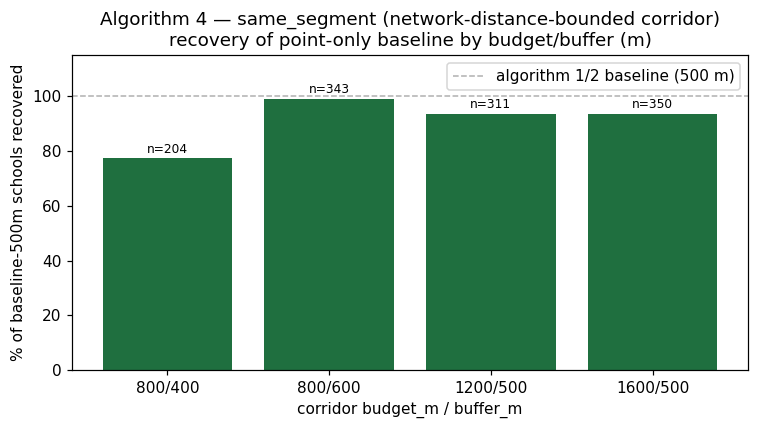

In [25]:
# Algorithm 4 (same_segment): recovery of the algorithm 1/2 baseline by corridor budget/buffer.
sweep = pd.DataFrame(rows)
labels = [f"{int(b)}/{int(u)}" for b, u in zip(sweep["budget_m"], sweep["buffer_m"])]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, sweep["recovers_of_baseline500"] * 100, color=GREEN)
ax.axhline(100, color=GREY, ls="--", lw=1, label="algorithm 1/2 baseline (500 m)")
for bar, n in zip(bars, sweep["n_schools"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"n={n}",
            ha="center", va="bottom", fontsize=8)
ax.set(title="Algorithm 4 — same_segment (network-distance-bounded corridor)\n"
             "recovery of point-only baseline by budget/buffer (m)",
       xlabel="corridor budget_m / buffer_m", ylabel="% of baseline-500m schools recovered")
ax.set_ylim(0, 115)
ax.legend()
fig.tight_layout()
savefig(fig, "schools_algo4_same_segment.png")

Recovery jumps from the naive design's ~20-35% to **93-99%**, and the
`max_straightline_m` column now tracks `budget + buffer` almost exactly at
every setting — confirming the leak is closed. `budget=800 m,
buffer=600 m` is a reasonable default (99.1% recovery, matches the school
set-back distances found in `road_network.ipynb` §2).

In [26]:
# Algorithm 5 on top: same-side test using each point's own nearest-arterial
# projection (the corridor test already establishes "same physical road";
# side still needs the geometric derivation from §7.2).
BUDGET_M, BUFFER_M = 800.0, 600.0
geoms, _ = zip(*[corridor_geometry(int(ir), pt, budget_m=BUDGET_M)
                  for ir, pt in zip(wj2["index_right"].to_numpy(), wj2["wall_pt"].to_numpy())])
corridors = gpd.GeoDataFrame({"gcid": wj2["gcid"].to_numpy()},
                              geometry=[g.buffer(BUFFER_M) for g in geoms], crs=major.crs)
joined = gpd.sjoin(placed[["msid", "geometry"]], corridors, predicate="within", how="inner")
print(f"corridor match: {len(joined)} pairs, {joined['msid'].nunique()} schools, "
      f"recovers={len(set(joined['msid']) & baseline_500) / len(baseline_500):.1%}")

pairs5 = (joined
          .merge(wj2[["gcid", "side"]].rename(columns={"side": "side_wall"}), on="gcid")
          .merge(sj2[["msid", "side"]].rename(columns={"side": "side_school"}), on="msid"))
same_side5 = pairs5["side_wall"] == pairs5["side_school"]
treated5 = set(pairs5.loc[same_side5, "msid"])
print(f"same-side share among corridor-matched pairs: {same_side5.mean():.1%} "
      f"({int(same_side5.sum())}/{len(pairs5)})")
print(f"algorithm 5 (corridor + same-side) treated schools: {len(treated5)}  "
      f"recovers_of_baseline500={len(treated5 & baseline_500) / len(baseline_500):.1%}")

corridor match: 1388 pairs, 343 schools, recovers=99.1%
same-side share among corridor-matched pairs: 61.0% (847/1388)
algorithm 5 (corridor + same-side) treated schools: 259  recovers_of_baseline500=83.2%


  saved output/figures/florida/schools_algo5_funnel.png


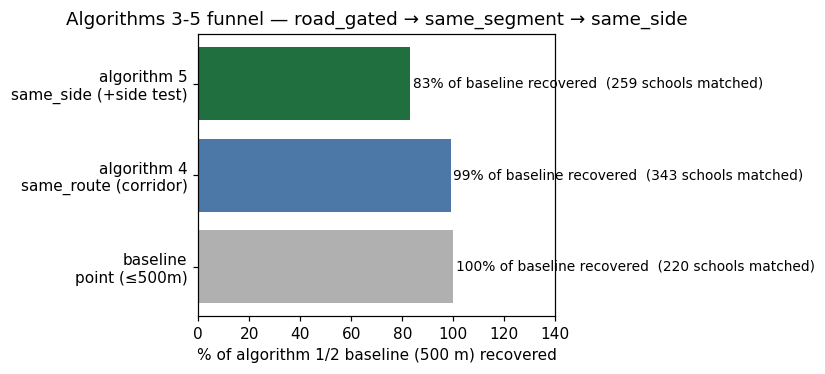

In [27]:
# Algorithm 5 (same_side): funnel from the point-only baseline through same_route to same_side.
recovered4 = len(set(joined["msid"]) & baseline_500)
recovered5 = len(treated5 & baseline_500)
funnel_labels = ["baseline\npoint (≤500m)", "algorithm 4\nsame_route (corridor)", "algorithm 5\nsame_side (+side test)"]
funnel_pct = [100.0, recovered4 / len(baseline_500) * 100, recovered5 / len(baseline_500) * 100]
funnel_totals = [len(baseline_500), joined["msid"].nunique(), len(treated5)]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(funnel_labels, funnel_pct, color=[GREY, BLUE, GREEN])
for bar, pct, total in zip(bars, funnel_pct, funnel_totals):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{pct:.0f}% of baseline recovered  ({total} schools matched)", va="center", fontsize=9)
ax.set(title="Algorithms 3-5 funnel — road_gated → same_segment → same_side",
       xlabel="% of algorithm 1/2 baseline (500 m) recovered")
ax.set_xlim(0, 140)
fig.tight_layout()
savefig(fig, "schools_algo5_funnel.png")

**Resolves Open Question 7.** Algorithms 3/4 (corridor match alone) recover
**99.1%** of the point-only baseline; algorithm 5 (+ same-side) recovers
**83.2%** — the ~17-point drop is schools whose nearest wall sits on the
*opposite* carriageway, exactly the false-positive class algorithm 5 exists
to remove from point-only matching, not a bug. This design — arterial-only
candidate network, network-distance-bounded corridor (not `ROADWAY`-id
equality), signed-offset side test — is ready to move into
`road_network/preprocess.py` (the adjacency graph + `corridor_geometry`
helper) and `schools/assemble.py` (`match_barriers_road`, filling
`PENDING_ROAD_COLUMNS`) as real pipeline code, with `budget=800 m,
buffer=600 m` as a documented starting default rather than the placeholder
`D`/`P` from §7.2-7.3.

### 7.5 Worked example map

  saved output/figures/florida/road_network_worked_example.png


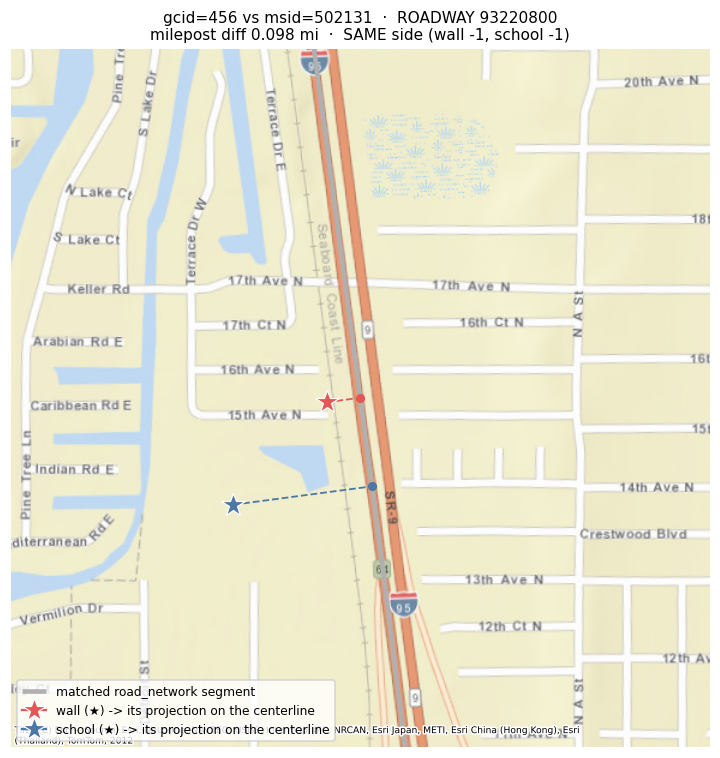

In [28]:
example = close.loc[close[["offset_m_wall", "offset_m_school"]].min(axis=1).idxmax()]
wall_row = wj[wj["gcid"] == example["gcid"]].iloc[0]
school_row = sj[sj["msid"] == example["msid"]].iloc[0]
road_line = wall_row["road_geometry"]

wall_proj = road_line.interpolate(road_line.project(wall_row["wall_pt"], normalized=True), normalized=True)
school_proj = road_line.interpolate(road_line.project(school_row["school_pt"], normalized=True), normalized=True)

fig, ax = plt.subplots(figsize=(7, 7))
gpd.GeoSeries([road_line], crs=3087).plot(ax=ax, color=GREY, linewidth=3, label="matched road_network segment")
for pt, proj, color, label in [
    (wall_row["wall_pt"], wall_proj, RED, "wall (★) -> its projection on the centerline"),
    (school_row["school_pt"], school_proj, BLUE, "school (★) -> its projection on the centerline"),
]:
    ax.plot(*pt.coords[0], marker="*", ms=16, color=color, mec="white", mew=0.8, zorder=5, label=label)
    ax.plot([pt.x, proj.x], [pt.y, proj.y], ls="--", lw=1.2, color=color)
    ax.plot(*proj.coords[0], marker="o", ms=5, color=color, zorder=5)

cx_, cy_ = wall_proj.x, wall_proj.y
span = max(150, example["offset_m_wall"], example["offset_m_school"]) * 2.5
ax.set_xlim(cx_ - span, cx_ + span)
ax.set_ylim(cy_ - span, cy_ + span)
add_basemap(ax, source=BASEMAP_STREET)
ax.set_axis_off()
ax.legend(loc="lower left", fontsize=8, frameon=True)
ax.set_title(
    f"gcid={example['gcid']} vs msid={example['msid']}  ·  ROADWAY {example['ROADWAY']}\n"
    f"milepost diff {example['milepost_diff_mi']:.3f} mi  ·  "
    f"{'SAME side' if example['side_wall'] == example['side_school'] else 'OPPOSITE side'} "
    f"(wall {example['side_wall']:+.0f}, school {example['side_school']:+.0f})",
    fontsize=10,
)
fig.tight_layout()
savefig(fig, "road_network_worked_example.png")

### 7.6 `REPLACED BARRIERS`' `FED_YRCON` — resolved via the FGDL metadata

Open TODO in `schools/README.md`: does `FED_YRCON` on a `REPLACED BARRIERS`
row hold the *original* construction year or the *replacement* year? Tried
the cheapest option first — actually reading the metadata XML's field-level
definition instead of guessing.

In [29]:
import xml.etree.ElementTree as ET

nb_xml = nb_raw_metadata_path(NB_VERSION, ROOT)
root_xml = ET.parse(nb_xml).getroot()
for attr in root_xml.iter("attr"):
    if attr.findtext("attrlabl") == "FED_YRCON":
        print("FED_YRCON definition (FGDL metadata):", attr.findtext("attrdef"))
        print("source:", attr.findtext("attrdefs"))

# Cross-check against the actual REPLACED rows in the raw GDB (barriers.parquet
# doesn't carry TYPE=REPLACED separately from category='fdot_barrier').
nb_gdb = nb_raw_gdb_path(NB_VERSION, ROOT)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Measured .* geometry types are not supported")
    raw_nb = gpd.read_file(nb_gdb)
replaced = raw_nb[raw_nb["TYPE"] == "REPLACED BARRIERS"]
print(f"\n{len(replaced)} REPLACED BARRIERS rows, FED_YRCON range "
      f"{replaced['FED_YRCON'].min():.0f}-{replaced['FED_YRCON'].max():.0f}")
print(replaced[["FED_YRCON"]].sort_values("FED_YRCON").to_string(index=False))

FED_YRCON definition (FGDL metadata): Year of Original Noise Barrier Construction.
source: GeoPlan

10 REPLACED BARRIERS rows, FED_YRCON range 1983-2009
 FED_YRCON
      1983
      1994
      1994
      1994
      2005
      2005
      2009
      2009
      2009
      2009


**Resolved.** FGDL's own field definition is unambiguous: *"Year of Original
Noise Barrier Construction."* The 10 `REPLACED BARRIERS` rows carry
plausible historical years (1983-2009, well before the `jul26` snapshot) —
consistent with "original," not "replacement." `schools/assemble.py`'s
existing assumption (`treat_year = built_year`, original year even for
`REPLACED`) is correct as documented; no code change needed, just remove the
TODO from `schools/README.md`.

### 7.7 New discovery: `noise_barriers` already carries a side-of-road field

While reading the metadata for §7.5, the attribute list turned up three
fields **not currently kept by `noise_barriers/preprocess.py`**:
`BLOC_ONRTE` ("Noise Barrier Construction Mount Type"), `BLOC_SIDE` ("Noise
Barrier Location Orientation to Roadway"), `BLOC_BND` ("Noise Barrier
Location Orientation to Roadway Traffic Direction"). This is exactly the
"roadbed/side field" `schools/README.md` flagged as a TODO to check for and
never found — because nobody had looked past the ~14 columns
`noise_barriers/preprocess.py`'s `COLUMN_RENAMES` already carries through.

In [30]:
present = raw_nb[raw_nb["TYPE"].isin(["CONSTRUCTED BARRIERS", "REPLACED BARRIERS"])]
for col in ("BLOC_ONRTE", "BLOC_SIDE", "BLOC_BND"):
    print(f"--- {col} (null share among present walls: {present[col].isna().mean():.1%} "
          f"/ blank-string share: {(present[col].astype(str).str.strip() == '').mean():.1%}) ---")
    print(present[col].value_counts(dropna=False).head(8))
    print()

--- BLOC_ONRTE (null share among present walls: 0.0% / blank-string share: 16.1%) ---
BLOC_ONRTE
SHOULDER MOUNTED              369
GROUND MOUNTED                350
NON-SHOULDER MOUNTED          261
                              201
SHOULDER/RETAINING MOUNTED     18
RAILING MOUNTED                16
SHOULDER/MSE WALL MOUNTED      11
STRUCTURE MOUNTED               6
Name: count, dtype: int64

--- BLOC_SIDE (null share among present walls: 0.0% / blank-string share: 0.0%) ---
BLOC_SIDE
EAST     507
WEST     354
SOUTH    199
NORTH    185
Name: count, dtype: int64

--- BLOC_BND (null share among present walls: 0.0% / blank-string share: 0.0%) ---
BLOC_BND
NORTH    543
SOUTH    374
EAST     164
WEST     163
 EAST      1
Name: count, dtype: int64



**Implication.** `BLOC_SIDE` is populated for every present wall with an
actual compass direction (`EAST`/`WEST`/`NORTH`/`SOUTH`) — a real, FDOT-
supplied side-of-road attribute that the whole geometric-derivation design
(algorithm 5 §7.2 above) was built to work around under the assumption that
no such field existed. `BLOC_ONRTE` (mount type: shoulder / ground / median /
structure-mounted) and `BLOC_BND` (orientation to traffic direction) are
populated too and carry related information.

**This does not fully replace algorithm 5** — `BLOC_SIDE` describes the
*wall's* side only; schools still need the geometric derivation, since they
have no equivalent attribute. But it changes the plan materially:

**Recommended next steps:**
1. Add `bloc_side`, `bloc_bnd`, `bloc_onrte` to `noise_barriers/preprocess.py`'s
   `COLUMN_RENAMES`/`OUTPUT_COLUMNS` — free columns, currently silently
   dropped.
2. Use `BLOC_SIDE` as a **ground-truth cross-check** for the geometric
   `wall_side` derived in §7.2: if a wall's derived sign and its `BLOC_SIDE`
   compass value correlate consistently within a `ROADWAY` (e.g., "sign +1
   always means EAST on this segment's orientation"), that validates the
   geometric method and could even let the `D`/`P` calibration (§7.3) use
   `BLOC_SIDE` agreement as its actual ground truth instead of a manual
   visual audit — a much cheaper calibration path than what was proposed
   before this field was found.
3. `BLOC_BND` may help distinguish which carriageway of a divided highway a
   wall sits on more directly than the signed-offset test — worth comparing
   once (1) lands.

## Notes & caveats

- **MSID code tables** are the authoritative FLDOE Appendix A/B values
  (`schools/msid_codes.py`); `GRADE_CODE` resolves ~85% of rows directly, a
  conservative CCD fallback (only plain grades 0-12, never CCD's ambiguous `-1`)
  fills some of the rest.
- **Single MSID issue** — open/close dates give the operation window, but
  charter/magnet/type *changes* before the snapshot are invisible.
- **CCD sentinels** `−1/−2/−3` → `NA` + `<col>_missing`; `crdc`/`crdc_lep`
  `year → +1` is confirmed (Urban's CRDC codebook defines `year` as "academic
  year, fall semester" — same convention as CCD); `edfacts` is spring-year
  indexed.
- **`pct_ell`** now comes from `crdc_lep` (endpoint 67, `.../lep/sex/`) — same
  biennial years and dedup treatment as `crdc_swd`'s `pct_swd`.
- **Coordinates:** ~240 active schools have no coordinate → `geocode_pending`;
  address geocoding is deferred.
- **Barrier matching** is point-only in the persisted pipeline
  (`schools_treatment.parquet`); `road_id` / `same_route` / `school_side` /
  `wall_side` are still `NA` there. §7 prototypes algorithms 3-5 against
  `road_network` but is **not wired into `assemble.py` yet** — the sensitivity
  check (§7.3) found the naive same-`ROADWAY`-id matching under-recovers the
  point-only baseline badly (~20-35%), so a corridor-based redesign is needed
  before this becomes real pipeline code, not just a tolerance tweak.
- **`REPLACED BARRIERS`' `FED_YRCON`** (§7.5) is confirmed to be the
  *original* construction year via the FGDL metadata — the TODO in this
  README is resolved, no code change needed.
- **New: `noise_barriers` has an unused side-of-road field** (§7.6) —
  `BLOC_SIDE`/`BLOC_BND`/`BLOC_ONRTE` exist in the raw GDB with real compass
  values for every present wall, currently dropped by
  `noise_barriers/preprocess.py`. Worth adding and using as ground truth for
  the geometric side derivation before trusting it blindly.
- Pipeline logic now lives in `schools/preprocess.py` + `schools/assemble.py`
  (imported above) with unit tests in
  `tests/regions/florida/test_schools_{preprocess,assemble}.py` — this notebook
  is investigation only, the way `assessments.ipynb` investigates its parser.
